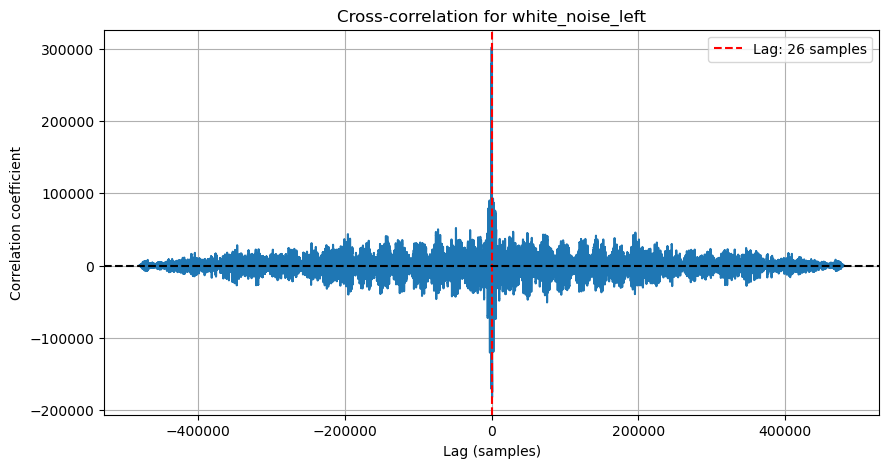

Fichier : white_noise_left
---------------------------------
Décalage : 26 échantillons (0.54 ms)


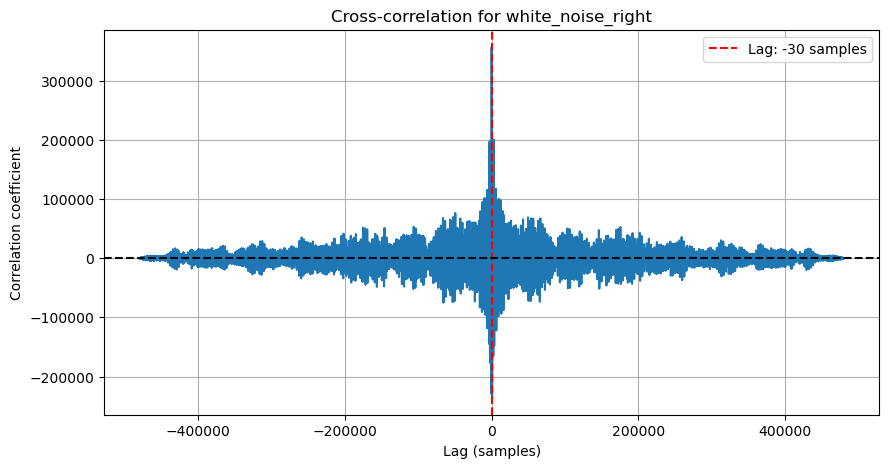

Fichier : white_noise_right
---------------------------------
Décalage : -30 échantillons (-0.62 ms)


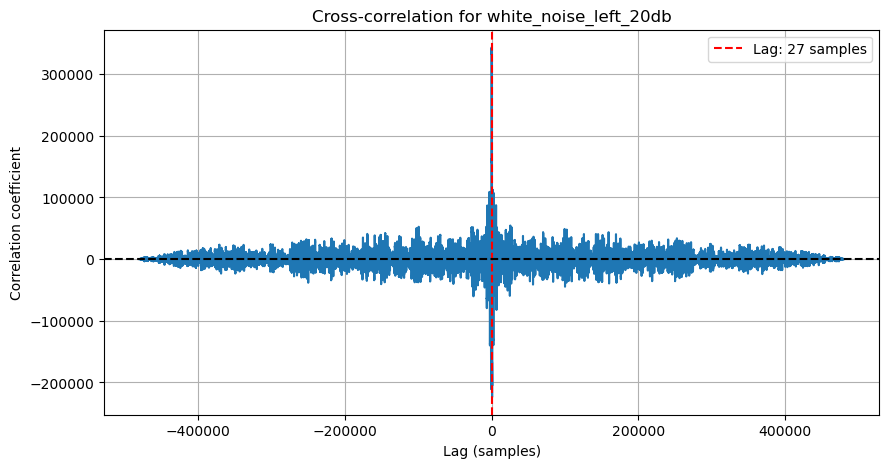

Fichier : white_noise_left_20db
---------------------------------
Décalage : 27 échantillons (0.56 ms)


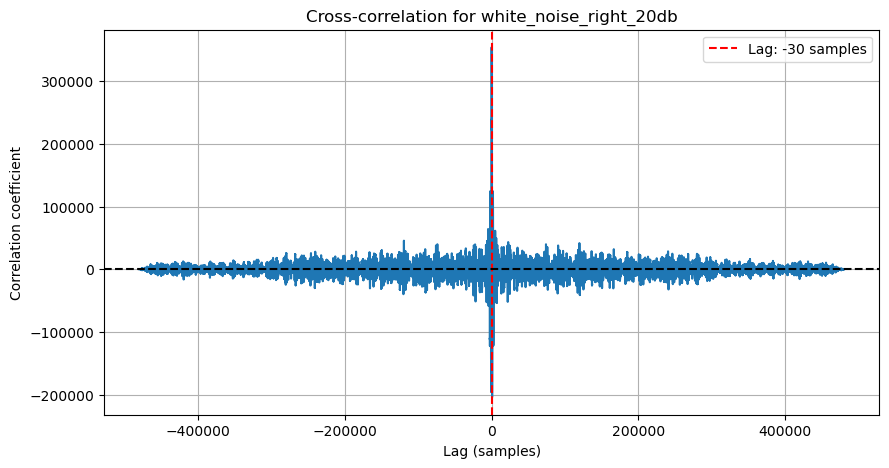

Fichier : white_noise_right_20db
---------------------------------
Décalage : -30 échantillons (-0.62 ms)


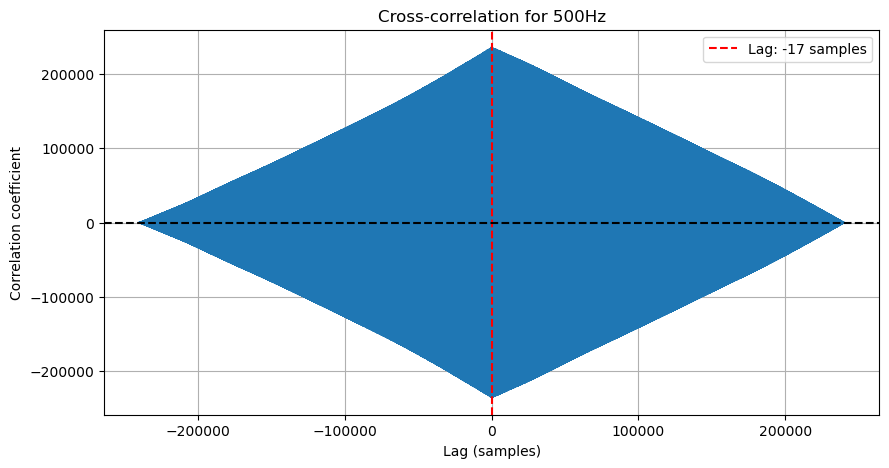

Fichier : 500Hz
---------------------------------
Décalage : -17 échantillons (-0.35 ms)
Résultats finaux :
Décalage moyen : (0.54 ms)


In [2]:
import numpy as np
import scipy.io.wavfile as wav
import matplotlib.pyplot as plt
from scipy.signal import correlate

# === 1. Charger le fichier audio .wav ===
lag_samples = []
samples = ["white_noise_left", "white_noise_right", "white_noise_left_20db", "white_noise_right_20db", "500Hz"]
for sample in samples:
    sample_rate, stereo_data = wav.read(f"white_noise/{sample}.wav")

    # === 2. Extraire les canaux gauche et droit ===
    left_channel = stereo_data[:, 0]
    right_channel = stereo_data[:, 1]

    # === 3. (Optionnel) Normalisation
    def normalize(signal):
        return (signal - np.mean(signal)) / (np.std(signal) + 1e-10)

    left_channel = normalize(left_channel)
    right_channel = normalize(right_channel)

    # === 4. Cross-corrélation
    cross_corr = correlate(left_channel, right_channel, mode='full')
    lags = np.arange(-len(left_channel) + 1, len(left_channel))

    # === 5. Trouver le pic de corrélation
    max_corr_index = np.argmax(cross_corr)
    lag_in_samples = lags[max_corr_index]
    lag_in_ms = lag_in_samples / sample_rate * 1000  # conversion en ms
    plt.figure(figsize=(10, 5))
    plt.plot(lags, cross_corr)
    plt.title(f"Cross-correlation for {sample}")
    plt.xlabel("Lag (samples)")
    plt.ylabel("Correlation coefficient")
    plt.axvline(x=lag_in_samples, color='r', linestyle='--', label=f'Lag: {lag_in_samples} samples')
    plt.axhline(y=0, color='k', linestyle='--')
    plt.legend()
    plt.grid()
    plt.show()
    
    lag_samples.append(lag_in_ms)

    # === 7. Impression du décalage
    print(f"======================================")
    print(f"Fichier : {sample}")
    print("---------------------------------")
    print(f"Décalage : {lag_in_samples} échantillons ({lag_in_ms:.2f} ms)")
lag_tot = 0
for lag in lag_samples:
    lag_tot += np.abs(lag)
lag_tot /= len(lag_samples)
print("======================================")
print("Résultats finaux :")
print("======================================")
print(f"Décalage moyen : ({lag_tot:.2f} ms)")


In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Parameters
sample_rate = 48000  # Sample rate in Hz


In [10]:

def BPF(f_min, f_max, sample_rate, nb_band, BW):
    """
    Band-pass filter design using the Butterworth filter.
    f_min: Minimum frequency of the band
    f_max: Maximum frequency of the band
    sample_rate: Sample rate of the signal
    nb_band: Number of bands to create
    BW: Bandwidth factor
    """
    duration = 100  # Duration of the white noise in seconds

    # Generate white noise
    noise = np.random.normal(0, 1, sample_rate * duration)

    # Normalize the white noise
    noise = noise / np.max(np.abs(noise))

    # Convert the white noise to a 16-bit format
    noise = (noise * 2**15).astype(np.int16)
    
    y = []
    f_center = np.geomspace(f_min, f_max, nb_band)
    for center in f_center:

        w0 = (2*np.pi * center) / sample_rate
        alpha = np.sin(w0) * np.sinh((np.log(2)/2) * BW * (w0 / np.sin(w0)))

        a0 = 1 + alpha
        b0 = (np.sin(w0) / 2) / a0
        b1 = 0
        b2 = (-np.sin(w0) / 2) / a0
        a1 = (-2 * np.cos(w0)) / a0
        a2 = (1 - alpha) / a0 

        xn1 = 0
        xn2 = 0
        yn1 = 0
        yn2 = 0

        yn_band = []
        for xn in noise:
            yn = b0 * xn + b1 * xn1 + b2 * xn2 - a1 * yn1 - a2 * yn2
            xn2 = xn1
            xn1 = xn
            yn2 = yn1
            yn1 = yn
            yn_band.append(yn)
        y.append(yn_band)

    return y, f_center




Band 1: Center Frequency = 100.00 Hz, Max FFT Amplitude at 100.32 Hz
Band 2: Center Frequency = 123.94 Hz, Max FFT Amplitude at 123.82 Hz
Band 3: Center Frequency = 153.60 Hz, Max FFT Amplitude at 153.91 Hz
Band 4: Center Frequency = 190.37 Hz, Max FFT Amplitude at 190.06 Hz
Band 5: Center Frequency = 235.93 Hz, Max FFT Amplitude at 235.29 Hz
Band 6: Center Frequency = 292.40 Hz, Max FFT Amplitude at 293.25 Hz
Band 7: Center Frequency = 362.39 Hz, Max FFT Amplitude at 362.31 Hz
Band 8: Center Frequency = 449.13 Hz, Max FFT Amplitude at 449.91 Hz
Band 9: Center Frequency = 556.63 Hz, Max FFT Amplitude at 557.25 Hz
Band 10: Center Frequency = 689.86 Hz, Max FFT Amplitude at 690.12 Hz
Band 11: Center Frequency = 854.99 Hz, Max FFT Amplitude at 855.44 Hz
Band 12: Center Frequency = 1059.63 Hz, Max FFT Amplitude at 1058.89 Hz
Band 13: Center Frequency = 1313.26 Hz, Max FFT Amplitude at 1312.70 Hz
Band 14: Center Frequency = 1627.60 Hz, Max FFT Amplitude at 1631.43 Hz
Band 15: Center Frequen

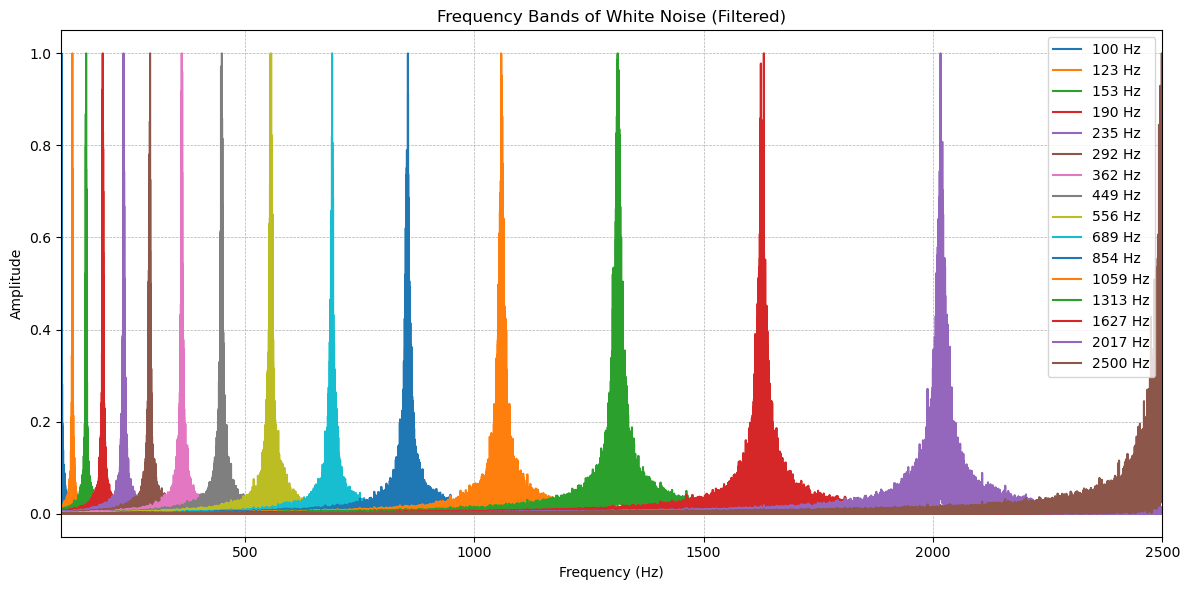

In [14]:
f_min = 100
f_max = 2500
nb_band = 16
BW = 0.01

y, f_center = BPF(f_min, f_max, sample_rate, nb_band, BW)
# Affichage du spectre
plt.figure(figsize=(12, 6))
plt.title("Frequency Bands of White Noise (Filtered)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
#plt.xscale('log')
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.xlim(f_min, f_max)

for i, y_n in enumerate(y):
    y_fft = np.fft.fft(y_n)
    freqs = np.fft.fftfreq(len(y_n), 1 / sample_rate)
    plt.plot(freqs[:len(freqs)//2], np.abs(y_fft[:len(freqs)//2]) / max(np.abs(y_fft)), label=f"{int(f_center[i])} Hz")
    max_idx = np.argmax(np.abs(y_fft[:len(freqs)//2]))
    max_freq = freqs[max_idx]
    print(f"Band {i+1}: Center Frequency = {f_center[i]:.2f} Hz, Max FFT Amplitude at {max_freq:.2f} Hz")

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


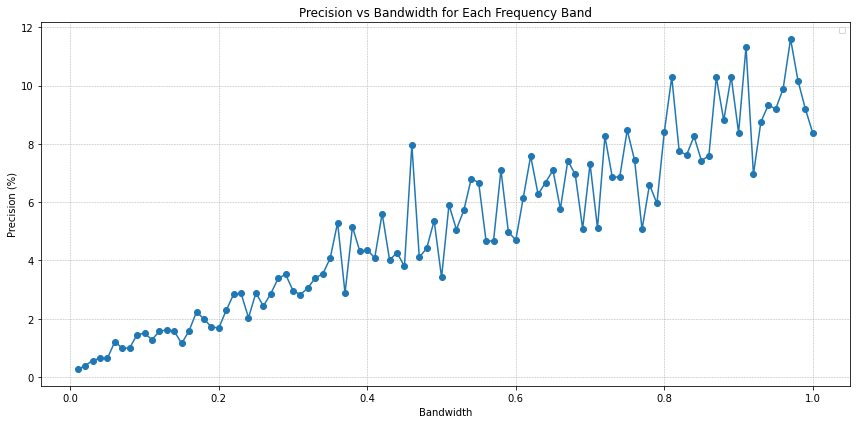

In [28]:
BW_test = np.linspace(0.01, 1, 100)
y_BW_test = []
for BW in BW_test:
    y, f_center = BPF(f_min, f_max, sample_rate, nb_band, BW)
    y_max_freq = []
    for i, y_n in enumerate(y):
        y_fft = np.fft.fft(y_n)
        freqs = np.fft.fftfreq(len(y_n), 1 / sample_rate)
        max_idx = np.argmax(np.abs(y_fft[:len(freqs)//2]))
        max_freq = freqs[max_idx]
        y_max_freq.append(max_freq)
    prec = (np.abs(f_center - np.array(y_max_freq))/f_center) * 100
    y_BW_test.append(prec)

plt.figure(figsize=(12, 6))
plt.title("Precision vs Bandwidth for Each Frequency Band")
plt.xlabel("Bandwidth")
plt.ylabel("Precision (%)")
plt.plot(BW_test, np.mean(y_BW_test, axis=1), marker='o')
plt.legend(loc='upper right', fontsize='small', ncol=2)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

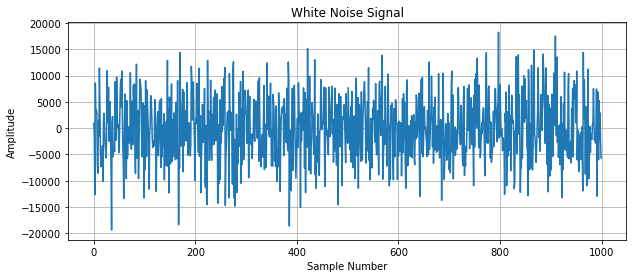

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(noise[:1000])  # Plot the first 1000 samples
plt.title("White Noise Signal")
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

In [15]:
from brian2 import *

In [18]:
# Ears parameters
sound_speed = 343.0*metre/second
distance_between_ears = 0.22*metre
sigma_ear = .1
tau_ear = 0.5*ms
max_delay = distance_between_ears / sound_speed
lam = 0.7  
# Coincidence detectors
num_neurons = 30
tau = 0.2*ms

# Thresholds
a = 1
p = 1.5
tau_thresh = 5*ms

# Filter parameters

f_min = 100 * Hz
f_max = 2500 * Hz  
nb_band = 16

BW = 0.1
fs = 48000 * Hz  
duration = 60*second
#sample_rate, stereo_data = wav.read("src/ros_standalone/examples/microphone/recorded_sound/WhN_RtoL.wav")
frequency = 440.0
amplitude = 32767.0 / 2
sound_speed = 343.0
distance = 0.2
max_delay = distance / sound_speed
BUFFER_SIZE = 1024
left_sample = []
right_sample = []
phase_shift = 0.0
for i in range(int(fs * duration)):
    if i % BUFFER_SIZE == 0:
       phase_shift += np.pi / 250
    left_delay = -0.5 * max_delay * np.sin(phase_shift)
    right_delay = 0.5 * max_delay * np.sin(phase_shift)

    left_sample.append(np.int16(amplitude * np.sin(2 * np.pi * frequency * (i - left_delay))))
    right_sample.append(np.int16(amplitude * np.sin(2 * np.pi * frequency * (i - right_delay))))

sound_left = TimedArray(left_sample, dt=defaultclock.dt)
sound_right = TimedArray(right_sample, dt=defaultclock.dt)

eqs_ears = '''
f_center = f_min * (f_max / f_min) ** ((i%nb_band) / (nb_band - 1)) : Hz # Logarithmic spacing of frequencies
xn = sound_left(t) * (1 - (i//nb_band)) + sound_right(t) * (i//nb_band) : 1 (constant over dt)

w0 = (2*pi * f_center) / fs : 1
alpha = sin(w0) * sinh((log(2)/2) * BW * (w0 / sin(w0))) : 1

a0 = 1 + alpha : 1
b0 = (sin(w0) / 2) / a0 : 1
b1 = 0 : 1
b2 = (-sin(w0) / 2) / a0 : 1
a1 = (-2 * cos(w0)) / a0 : 1
a2 = (1 - alpha) / a0 : 1

yn = b0 * xn + b1 * xn1 + b2 * xn2 - a1 * yn1 - a2 * yn2 : 1 (constant over dt)

yn1 : 1
yn2 : 1

xn2 : 1 
xn1 : 1 

dx/dt = (yn - x)/tau_ear : 1 (unless refractory)
dthresh/dt = (a * clip(x, 0, inf) - thresh) / tau_thresh : 1
'''

reset = '''
x = 0
thresh = p * thresh + lam * x
'''

ears = NeuronGroup(2 * nb_band, eqs_ears, threshold='x>thresh and x>5000',reset=reset,
                    name='ears', method='euler',refractory=0.5*ms)
ears.run_regularly('xn2 = xn1 ; xn1 = xn ; yn2 = yn1 ; yn1 = yn', dt=defaultclock.dt, when='end')


ears.thresh = np.ones(2 * nb_band) * 5000  # Initialize thresholds

eqs_neurons = '''
dv/dt = -v / tau : 1
'''
neurons = NeuronGroup(num_neurons * nb_band, eqs_neurons, threshold='v>1',
                       reset='v=0', name='neurons', method='euler',refractory=10*ms)
# Connect ears to neurons
synapses = Synapses(ears, neurons, on_pre='v += .65')
synapses.connect('i % nb_band == j // num_neurons')  

synapses.delay['i//nb_band==0'] = '(1.0*j)/(num_neurons-1)*1.1*max_delay'
synapses.delay['i//nb_band==1'] = '(1.0*(num_neurons-j-1))/(num_neurons-1)*1.1*max_delay'

#wta = Synapses(neurons, neurons, on_pre='v -= 0.65')  
#wta.connect(condition='i != j') 

tau_radar = 250 * ms  # Time constant for the radar
num_radar = 5

eqs_radar = '''
dv/dt = -v / tau_radar: 1
'''

radar = NeuronGroup(num_radar * nb_band, eqs_radar, threshold='v>1', method='euler', name='radar', reset='v=0')
radar_synapses = Synapses(neurons, radar, on_pre='v += 0.65')
radar_synapses.connect(condition='j == i//(num_neurons//num_radar)')

eqs_combi = '''
dv/dt = -v / tau_radar : 1
'''
combination = NeuronGroup(num_radar, eqs_combi, threshold='v>1', reset='v=0', method='euler', name='combination')
combination_synapses = Synapses(radar, combination, on_pre='v += 0.30')
combination_synapses.connect('i == j % num_radar') 

num_direction = 2 # Left and Right
tau_direction = 2 * ms  
tau_target = 50 * ms

eqs_direction = '''
dv/dt = clip(-v, -1.82, 1.82) / tau_direction : 1
dvel/dt = (v - vel) / tau_target : 1
'''

direction = NeuronGroup(num_direction, eqs_direction, method='euler', name='direction', dt=defaultclock.dt)
direction_synapses = Synapses(combination, direction, on_pre='v += 1.6 * sin(1.82348*i + 1.06544) + 0.6')
direction_synapses.connect(i=[0,1,2], j=0)
direction_synapses.connect(i=[2,3,4], j=1)

   
s_yn1 = StateMonitor(ears, 'yn1', record=True)
s_yn2 = StateMonitor(ears, 'yn2', record=True)
s_xn1 = StateMonitor(ears, 'xn1', record=True)
s_xn2 = StateMonitor(ears, 'xn2', record=True)
s_xn = StateMonitor(ears, 'xn', record=True)

radar_spikes = SpikeMonitor(radar)
spikes = SpikeMonitor(neurons)
combi = SpikeMonitor(combination)
ears_spikes = SpikeMonitor(ears)

# Ne peut pas etre utilise en un seul state monitor
sound = StateMonitor(ears, 'yn', record=True)
combi_state = StateMonitor(combination, 'v', record=True)
radar_state = StateMonitor(radar, 'v', record=True)
thresh = StateMonitor(ears, 'thresh', record=True)
son = StateMonitor(ears, 'x', record=True)
dir = StateMonitor(direction, 'v', record=True)
dir_vel = StateMonitor(direction, 'vel', record=True)

run(60 * second, report="text", report_period=5 * second)


WARNING    'i' is an internal variable of group 'synapses_2', but also exists in the run namespace with the value 2879999. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    The object 'ears' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/tmp/ipykernel_5812/1001472743.py', line 58, in <module>
    ears = NeuronGroup(2 * nb_band, eqs_ears, threshold='x>thresh and x>5000',reset=reset, [brian2.core.base.unused_brian_object]
WARNING    The object 'synapses' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/tmp/ipykernel_5812/10

DimensionMismatchError: The right-hand-side of code statement "delay = (1.0*j)/(num_neurons-1)*1.1*max_delay" does not have the expected unit s (unit is 1).